# 02 — Análise exploratória das fatalidades

Análise descritiva de registros individuais de fatalidades no conflito israelense-palestino. O conjunto cobre eventos de 2 de outubro de 2000 a 24 de setembro de 2023.

## Perguntas de análise

1. Como os registros variam ao longo do tempo?
2. Qual é a distribuição por cidadania, gênero, faixa etária e região do evento?
3. O que a base registra sobre participação em hostilidades?
4. Em quantos casos a morte ocorreu após o evento?

> **Limite de interpretação:** os resultados descrevem os atributos registrados na fonte. Eles não comprovam causalidade, responsabilidade legal ou completude dos registros.

In [1]:
from pathlib import Path
import sys
import pandas as pd

RAIZ_PROJETO = Path.cwd()
if not (RAIZ_PROJETO / 'src').exists():
    RAIZ_PROJETO = RAIZ_PROJETO.parent
sys.path.insert(0, str(RAIZ_PROJETO / 'src'))

from data_processing import PROCESSED_DATA_PATH
from analysis_utils import tabela_frequencia, fatalidades_por_ano, grafico_barras, grafico_linha_anual

## Carregamento da base processada

In [2]:
if not PROCESSED_DATA_PATH.exists():
    raise FileNotFoundError('Execute primeiro o notebook 01_preprocessamento.ipynb.')

dados = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['date_of_event', 'date_of_death'])
print(f'Registros analisados: {len(dados):,}')
dados.head()

Registros analisados: 11,124


,name,date_of_event,age,citizenship,event_location,event_location_district,event_location_region,date_of_death,gender,took_part_in_the_hostilities,place_of_residence,place_of_residence_district,type_of_injury,ammunition,killed_by,notes,ano_evento,ano_obito,faixa_etaria,dias_ate_obito
0,'Abd a-Rahman Suleiman Muhammad Abu Daghash,2023-09-24,32.0,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,Desconhecido,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,Fatally shot by Israeli forces while standing ...,2023,2023,25–34,0
1,Usayed Farhan Muhammad 'Ali Abu 'Ali,2023-09-24,21.0,Palestinian,Nur Shams R.C.,Tulkarm,West Bank,2023-09-24,M,Desconhecido,Nur Shams R.C.,Tulkarm,gunfire,live ammunition,Israeli security forces,Fatally shot by Israeli forces while trying to...,2023,2023,15–24,0
2,'Abdallah 'Imad Sa'ed Abu Hassan,2023-09-22,16.0,Palestinian,Kfar Dan,Jenin,West Bank,2023-09-22,M,Desconhecido,al-Yamun,Jenin,gunfire,live ammunition,Israeli security forces,Fatally shot by soldiers while firing at them ...,2023,2023,15–24,0
3,Durgham Muhammad Yihya al-Akhras,2023-09-20,19.0,Palestinian,'Aqbat Jaber R.C.,Jericho,West Bank,2023-09-20,M,Desconhecido,'Aqbat Jaber R.C.,Jericho,gunfire,live ammunition,Israeli security forces,Shot in the head by Israeli forces while throw...,2023,2023,15–24,0
4,Raafat 'Omar Ahmad Khamaisah,2023-09-19,15.0,Palestinian,Jenin R.C.,Jenin,West Bank,2023-09-19,M,Desconhecido,Jenin,Jenin,gunfire,live ammunition,Israeli security forces,Wounded by soldiers’ gunfire after running awa...,2023,2023,15–24,0


## Evolução anual

A série usa o ano do óbito — e não o ano do evento — para manter a definição temporal consistente.

,ano_obito,fatalidades
0,2000,35
1,2001,348
2,2002,1326
3,2003,732
4,2004,922
5,2005,240
6,2006,681
7,2007,400
8,2008,900
9,2009,1059


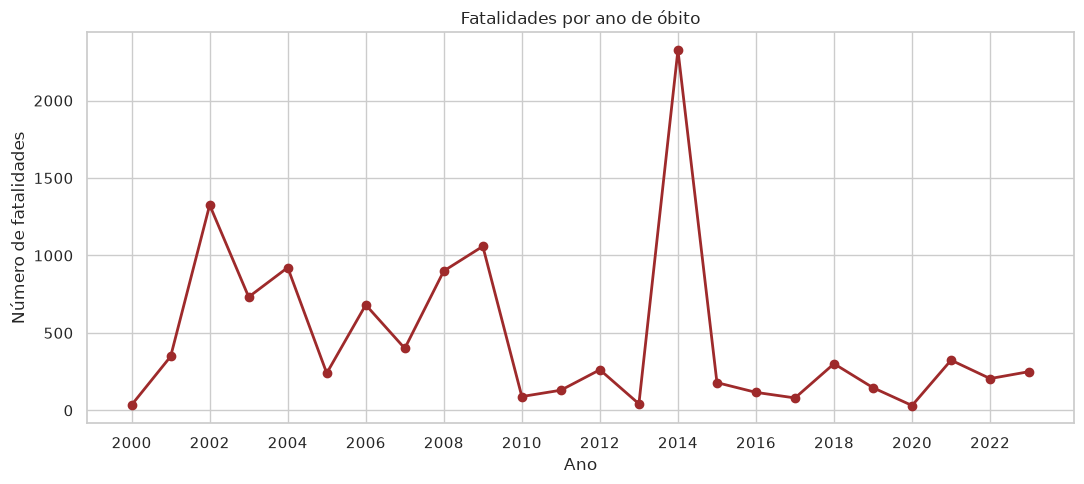

In [3]:
por_ano = fatalidades_por_ano(dados)
fig, _ = grafico_linha_anual(por_ano)
por_ano

## Perfil dos registros

,citizenship,fatalidades,percentual
0,Palestinian,10092,90.72
1,Israeli,1029,9.25
2,Jordanian,2,0.02
3,American,1,0.01


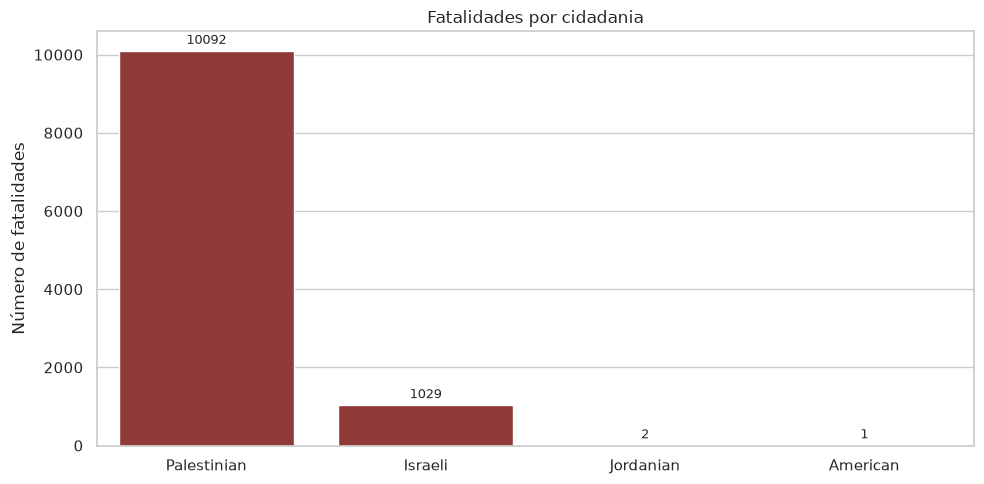

In [4]:
por_cidadania = tabela_frequencia(dados, 'citizenship')
fig, _ = grafico_barras(por_cidadania, 'citizenship', 'Fatalidades por cidadania', rotacao=0)
por_cidadania

,event_location_region,fatalidades,percentual
0,Gaza Strip,7733,69.52
1,West Bank,2712,24.38
2,Israel,679,6.10


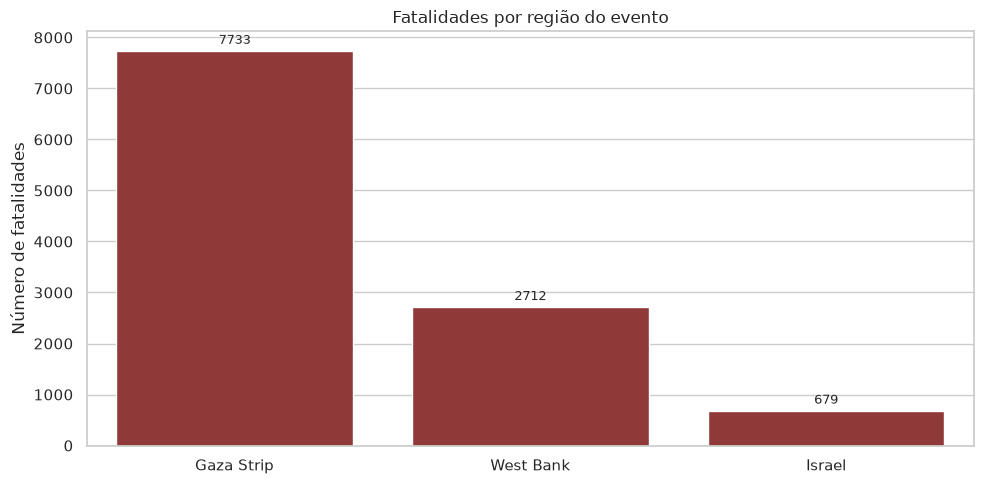

In [5]:
por_regiao = tabela_frequencia(dados, 'event_location_region')
fig, _ = grafico_barras(por_regiao, 'event_location_region', 'Fatalidades por região do evento', rotacao=0)
por_regiao

,faixa_etaria,fatalidades,percentual
0,15–24,4893,44.50
1,25–34,2723,24.77
2,0–14,1164,10.59
3,35–44,1002,9.11
4,45–54,616,5.60
5,55–64,323,2.94
6,65+,274,2.49


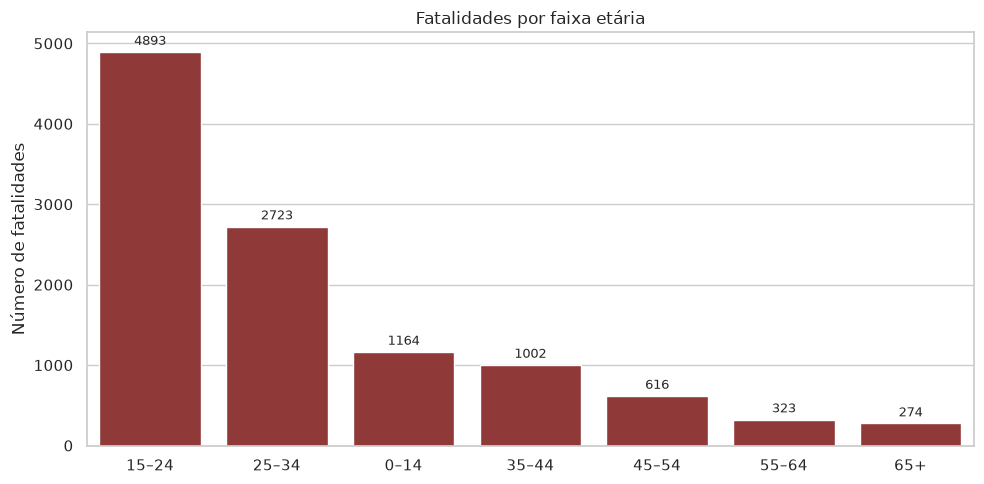

In [6]:
dados_com_idade = dados.dropna(subset=['faixa_etaria'])
por_faixa_etaria = tabela_frequencia(dados_com_idade, 'faixa_etaria')
fig, _ = grafico_barras(por_faixa_etaria, 'faixa_etaria', 'Fatalidades por faixa etária', rotacao=0)
por_faixa_etaria

## Participação em hostilidades e defasagem entre evento e óbito

,took_part_in_the_hostilities,fatalidades,percentual
0,No,4653,41.83
1,Yes,3467,31.17
2,Desconhecido,1430,12.86
3,Israelis,771,6.93
4,Unknown,603,5.42
5,Object of targeted killing,200,1.80


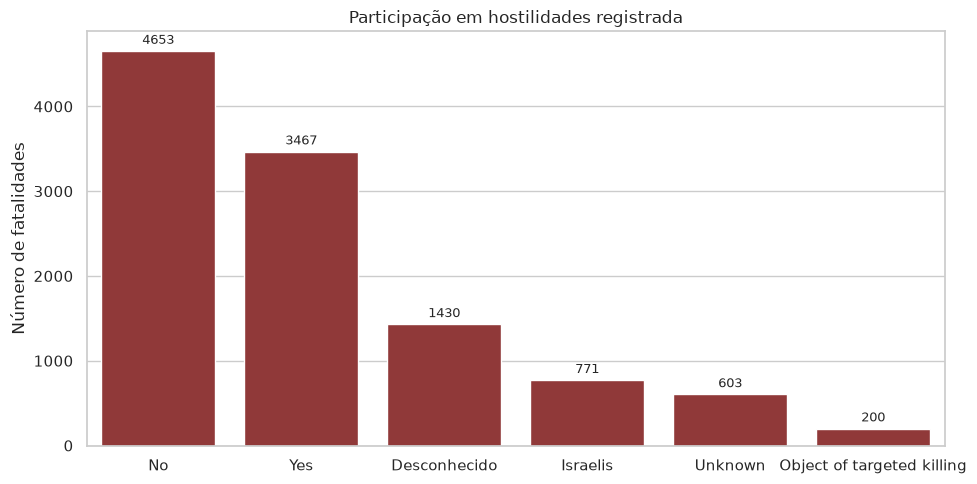

In [7]:
por_hostilidades = tabela_frequencia(dados, 'took_part_in_the_hostilities')
fig, _ = grafico_barras(por_hostilidades, 'took_part_in_the_hostilities', 'Participação em hostilidades registrada', rotacao=0)
por_hostilidades

In [8]:
mortes_posteriores = (dados['dias_ate_obito'] > 0).sum()
percentual = mortes_posteriores / len(dados) * 100
print(f'{mortes_posteriores:,} registros ({percentual:.2f}%) têm morte posterior ao evento.')

910 registros (8.18%) têm morte posterior ao evento.


## Conclusão

Esta análise é exploratória. Antes de produzir conclusões substantivas, avalie a documentação da fonte, a cobertura dos registros e as categorias classificadas como desconhecidas.